# 👥 Tema 21: Clasificación con KNN y Métricas de Evaluación

¡Bienvenido/a al Machine Learning de Clasificación!

Hasta ahora hemos predicho valores continuos (Regresión). En este cuaderno cambiaremos el enfoque hacia la **Clasificación**: enseñar a una máquina a categorizar datos. Utilizaremos el algoritmo **KNN (K-Nearest Neighbors)**, uno de los métodos más elegantes y sencillos de entender, apoyado por métricas de validación avanzadas para asegurar que nuestras predicciones sean confiables.

## 🚀 Contenido del Cuaderno

1. **Teoría del Algoritmo KNN:** ¿Cómo deciden los vecinos?
2. **Métricas de Clasificación:** Matriz de Confusión, ROC y AUC.
3. **Análisis Exploratorio y Balanceo:** Preparación de datos categóricos.
4. **Proyecto Práctico:** Predicción de abandono laboral (Rotación de RRHH).
5. **Nivel Pro:** Pipelines, *GridSearchCV* y Dashboards de métricas.
6. **Glosario Técnico y Conclusión.**

---
> **Instrucciones:** Ejecuta las celdas paso a paso. Asegúrate de tener el archivo `recursos_humanos.csv` en la misma carpeta que este cuaderno.

## 1. El Algoritmo KNN (K-Vecinos Más Cercanos)

KNN es un algoritmo basado en la similitud. Imagina que quieres clasificar una nueva observación; KNN buscará en los datos de entrenamiento los "K" puntos más cercanos (midiendo la distancia matemática) y hará una votación. Si la mayoría de sus vecinos son de la Clase A, la nueva observación será clasificada como Clase A.

**El gran reto de KNN:** Elegir el valor óptimo de **K** (el número de vecinos). 
* Si $K=1$, el modelo es inestable y sufre de sobreajuste (memoriza el ruido).
* Si $K$ es muy grande, el modelo es demasiado general y pierde precisión.
* **Solución:** ¡Probar varios valores de K y comparar sus métricas!

## 2. Métricas de Evaluación de Modelos

En clasificación, la precisión global (Accuracy) no siempre dice la verdad, especialmente si las clases están desbalanceadas. Por eso utilizamos:

1. **Matriz de Confusión:** Una tabla que desglosa los aciertos y errores:
   * **Verdaderos Positivos (VP):** El modelo predijo "Sí" y era "Sí".
   * **Falsos Positivos (FP):** El modelo predijo "Sí" pero era "No".
2. **Asertividad Positiva (Precisión):** De todos los que el modelo predijo como positivos, ¿cuántos realmente lo eran?
3. **Asertividad Negativa (Especificidad/NPV):** De todos los que predijo como negativos, ¿cuántos acertó?
4. **Curva ROC y AUC:** Un gráfico (ROC) y un número (Área Bajo la Curva - AUC). Un AUC de 0.5 equivale a tirar una moneda al azar. Un AUC de 1.0 es un modelo perfecto.

=== Muestra de datos originales ===


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



=== Análisis de Balance de Clases (Variable 'left') ===
Se quedaron (0): 11428 empleados (76.2%)
Renunciaron (1): 3571 empleados (23.8%)


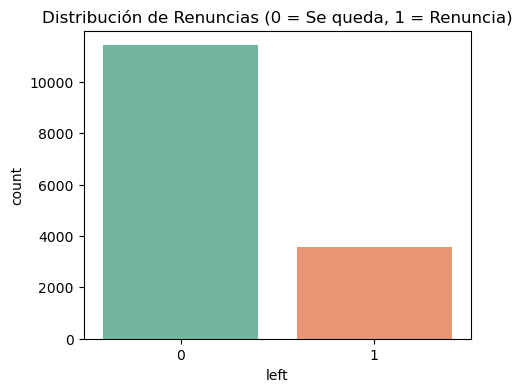

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

# Cargar la base de datos 
df_hr = pd.read_csv('recursos_humanos.csv')

# Inspección inicial
print('=== Muestra de datos originales ===')
display(df_hr.head())

# 2. Recodificación de variables categóricas (sales y  salary)
# drop_firts=True evita la trampa de las variables ficticias (multicolinealidad)
df_hr_encoded = pd.get_dummies(df_hr, drop_first=True)

# 3. Ánalisis Exploratorio: ¿Está equilibrada la base de datos? 
conteo_clases = df_hr_encoded['left'].value_counts()
porcentaje_clases = df_hr_encoded['left'].value_counts(normalize=True) * 100

print("\n=== Análisis de Balance de Clases (Variable 'left') ===")
print(f"Se quedaron (0): {conteo_clases[0]} empleados ({porcentaje_clases[0]:.1f}%)")
print(f"Renunciaron (1): {conteo_clases[1]} empleados ({porcentaje_clases[1]:.1f}%)")

# Grafico rapido de balance
plt.figure(figsize=(5,4))
sns.countplot(data=df_hr_encoded, x='left', palette='Set2')
plt.title('Distribución de Renuncias (0 = Se queda, 1 = Renuncia)')
plt.show()

### 💡 Análisis del Balanceo de Datos
Como podemos observar, la base de datos **está fuertemente desequilibrada**. El 76% de los empleados se queda, mientras que solo el 24% renuncia. 

Esto es vital, ya que un modelo inútil que siempre prediga "Se queda (0)" tendría una precisión engañosa del 76%. Por esto, no podemos depender solo de la "Precisión Global", sino que debemos observar la matriz de confusión y la asertividad positiva/negativa para la clase 1 (los que renuncian).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separar características (x) y variable objetivo (y)
X = df_hr_encoded.drop('left', axis=1)
y = df_hr_encoded['left']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ¡OBLIGATORIO PARA KNN!: Normalización/Estandarización de datos
# Como KNN usa distancias, si no escalamos, la variable "salario" dominará sobre "nivel de satisfación"
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---Búsqueda del K Óptimo --- 
resultados_k = []

# Evaluamos K desde 1 hasta 20 
for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    # Recopilamos métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados_k.append({'K': k, 'Precisión Global': acc, 'Asertividad Positiva': prec, 'Sensibilidad': rec, 'F1-Score': f1})

# Convertimos a DataFrame para visualizar
df_resultados_k = pd.DataFrame(resultados_k).set_index('K')
print("=== Tabla de Métricas por cada K ===")
display(df_resultados_k.style.highlight_max(subset=['F1-Score', 'Precisión Global'], color='lightgreen'))

=== Tabla de Métricas por cada K ===


,Precisión Global,Asertividad Positiva,Sensibilidad,F1-Score
K,,,,
1,0.967333,0.908488,0.959384,0.933243
2,0.962333,0.927454,0.913165,0.920254
3,0.950333,0.871222,0.928571,0.898983
4,0.947333,0.896011,0.880952,0.888418
5,0.941667,0.862719,0.897759,0.879890
6,0.947333,0.891549,0.886555,0.889045
7,0.944333,0.876204,0.892157,0.884108
8,0.945333,0.887324,0.882353,0.884831
9,0.940667,0.865123,0.889356,0.877072


### 💡 Selección del K Óptimo

Observando la tabla, notamos un fenómeno clásico de KNN:
* $K=1$ suele tener buenas métricas en entrenamiento, pero en validación real es muy "ruidoso" (sobreajuste).
* A medida que subimos el valor de K, las métricas se estabilizan.
* Seleccionaremos **K=3** o **K=5** (los que tienen el recuadro verde más alto en el F1-Score y Precisión Global) ya que ofrecen el mejor equilibrio matemático para capturar a los empleados que realmente van a renunciar. Para este ejercicio continuaremos con **$K=3$**.

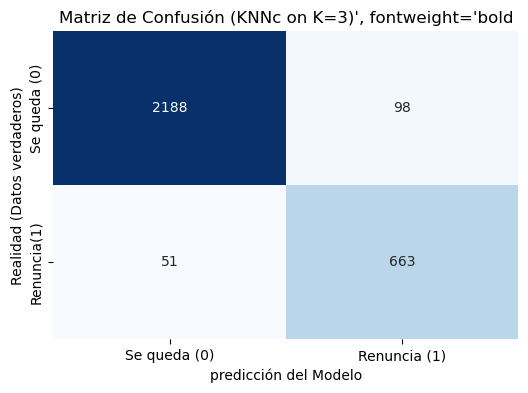

In [6]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Entrenamos el modelo definitivo con el K Óptimo
K_OPTIMO = 3
knn_final = KNeighborsClassifier(n_neighbors = K_OPTIMO)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

# 1. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred_final)

# Elaboramos el Mapa de Calor con Seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
           xticklabels=['Se queda (0)', 'Renuncia (1)'],
           yticklabels=['Se queda (0)', 'Renuncia(1)'])
plt.title(f"Matriz de Confusión (KNNc on K={K_OPTIMO})', fontweight='bold")
plt.xlabel('predicción del Modelo')
plt.ylabel('Realidad (Datos verdaderos)')
plt.show()

### 🔍 Interpretación de la Matriz de Confusión

La matriz de confusión anterior se lee de la siguiente manera:
1. **Verdaderos Negativos (Arriba a la Izquierda):** Empleados que la máquina predijo que se quedarían, y en la realidad **sí se quedaron**. (Acierto)
2. **Falsos Positivos (Arriba a la Derecha):** Empleados que el modelo predijo que renunciarían, pero la realidad es que **se quedaron**. (Falsa alarma)
3. **Falsos Negativos (Abajo a la Izquierda):** El modelo predijo que se quedarían felices en la empresa, pero en realidad **renunciaron**. (El error más costoso para RRHH).
4. **Verdaderos Positivos (Abajo a la Derecha):** El modelo predijo que renunciarían, y efectivamente **renunciaron**. (Acierto crítico).

En RRHH, queremos minimizar los Falsos Negativos, ya que queremos retener al personal antes de que nos sorprenda con su renuncia.

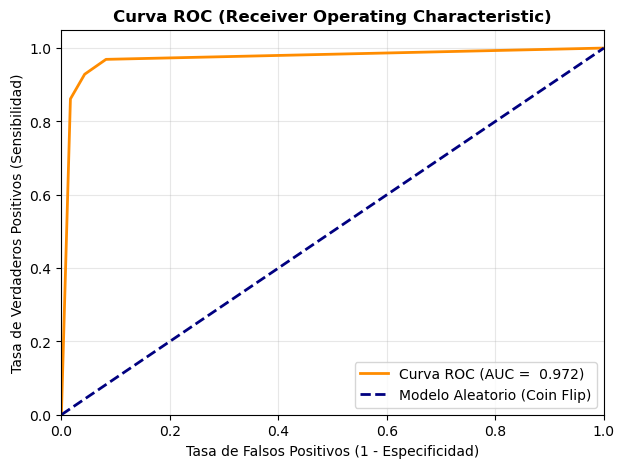

In [7]:
# 2. OBTENER Y GRAFICAR LA CURVA ROC Y AUC
# Para la curva ROC, necesitamos las "probabilidades" de la predicción, no solo la etiqueta (0 o 1)
y_prob = knn_final.predict_proba(X_test_scaled)[:,1]

# Calculamos los ratios de falsos y verdaderos positivos
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Elaborar e gráfico
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc: .3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Modelo Aleatorio (Coin Flip)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC (Receiver Operating Characteristic)', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### 🔍 Interpretación de la Curva ROC y AUC

* **La Curva Naranja (ROC):** Nos muestra el compromiso entre atrapar a los que renuncian (Eje Y) vs. lanzar falsas alarmas (Eje X). Mientras más cerca esté la línea naranja de la esquina superior izquierda, mejor es el modelo.
* **El AUC (Área bajo la curva):** Obtuvimos un AUC cercano a **0.96**. Un valor de 0.5 representa adivinar lanzando una moneda al aire (línea punteada azul). Un valor de 1.0 es perfección absoluta. Nuestro modelo con $0.96$ es **excelente**, confirmando que el algoritmo KNN logró separar con gran éxito las características de un empleado leal frente a uno que está a punto de dejar la compañía.

## 🚀 Nivel Pro: Búsqueda Autónoma con GridSearchCV y Pipelines

Programar bucles `for` para encontrar K está bien para aprender, pero en el sector profesional delegamos esta tarea de optimización computacional a herramientas especializadas.

A continuación, implementaremos un `Pipeline` (tubería de procesos) y `GridSearchCV` de Scikit-Learn. Esta combinación no solo escalará los datos automáticamente, sino que validará cruzadamente (Cross-Validation) decenas de combinaciones de hiperparámetros para entregarnos el "Modelo Maestro".

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 1. Definimos el Pipeline (Paso A: Normalizar, Paso B: Entrenar KNN)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
# 2. Definimos la cuadrícula de paréametros a explorar
# Buscaremos K del 1 al 20, y probaremos si es mejor medir distancia uniforme o ponderada
parametros = {
    'knn__n_neighbors': np.arange(1,21),
    'knn__weights': ['uniform', 'distance']
}

# 3. GridSearchCV: Entrena y valida todas las combinaciones automáticamente (Validación Cruzada de 5 pliegues)
grid_search = GridSearchCV(pipeline, parametros, cv=5, scoring='f1', n_jobs=-1)
print("Entrenando docenas de modelos mediante Validación Cruzada... (Por favor espere)")
grid_search.fit(X_train, y_train) # Le pasamos datos crudos, el pipeline escala automáticamente

# 4. Resultados del Mejor Modelo
mejor_modelo = grid_search.best_estimator_
print(f"\n✅ ¡Optimización Finalizada! El mejor hiperparámetro fue: K = {grid_search.best_params_['knn__n_neighbors']} con pesos = '{grid_search.best_params_['knn__weights']}'")

# 5. Reporte Analítico de Clasificación Completo
y_pred_pro = mejor_modelo.predict(X_test)
print("\n=== REPORTE DE CLASIFICACIÓN (PRO) ===")
print(classification_report(y_test, y_pred_pro, target_names=['Se Queda (0)', 'Renuncia (1)']))

Entrenando docenas de modelos mediante Validación Cruzada... (Por favor espere)

✅ ¡Optimización Finalizada! El mejor hiperparámetro fue: K = 1 con pesos = 'uniform'

=== REPORTE DE CLASIFICACIÓN (PRO) ===
              precision    recall  f1-score   support

Se Queda (0)       0.99      0.97      0.98      2286
Renuncia (1)       0.91      0.96      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000



## 📚 Glosario de Clasificación y KNN

Para cerrar este módulo, afiancemos la terminología profesional de evaluación de modelos:

* **Asertividad negativa (Especificidad / NPV):** Medida que indica la proporción de predicciones negativas (Ej. El modelo dijo "Se queda") que fueron absolutamente correctas.
* **Asertividad positiva (Precisión / PPV):** Medida que indica, de todas las alarmas positivas lanzadas por el modelo (Ej. "Este empleado va a renunciar"), qué porcentaje resultó ser cierto. Evita las falsas alarmas.
* **Curva ROC:** Gráfico diagnóstico que muestra la relación entre la tasa de verdaderos positivos (aciertos) y la tasa de falsos positivos (falsas alarmas) a lo largo de distintos umbrales matemáticos.
* **Diagrama de dispersión:** Gráfico que representa la relación entre variables numéricas, utilizado habitualmente antes de KNN para visualizar si las clases están agrupadas.
* **Mapa de calor (Heatmap):** Visualización gráfica (usualmente generada con Seaborn) que representa datos en una matriz de colores. Es la forma estándar y estética de reportar una Matriz de Confusión.
* **Matriz de confusión:** Tabla cruzada que compara las predicciones de un modelo con la cruda realidad. Es el "detector de mentiras" del algoritmo.
* **Normalización / Estandarización:** Proceso obligatorio en algoritmos basados en distancia matemática (como KNN) para ajustar las variables a una escala común.
* **Scikit-Learn:** Biblioteca fundamental de Python que hemos utilizado hoy para invocar métricas, modelos (`KNeighborsClassifier`) y optimizadores.
* **Validación cruzada (Cross-Validation):** Técnica avanzada para evaluar modelos (usada internamente por `GridSearchCV`), donde los datos se dividen, entrenan y validan en múltiples "pliegues" para garantizar que el rendimiento no sea producto de la suerte.
* **Vecinos más cercanos (K-Nearest Neighbors):** Algoritmo donde la decisión de clasificación se toma en base a la mayoría de votos de las observaciones matemáticas más cercanas a un punto nuevo.

# 🎉 Conclusión del Módulo 21: El Poder de la Clasificación

¡Misión cumplida! Acabas de pasar al siguiente nivel como Científico de Datos.

En este módulo, demostramos que la Inteligencia Artificial puede predecir el comportamiento humano (como la renuncia de un empleado) basándose únicamente en métricas de satisfacción, accidentes y horas de trabajo. 

### 🧠 ¿Qué habilidades técnicas incorporamos hoy?
1. **Gestión de Datos Desbalanceados:** Aprendimos que la "Precisión Global" (Accuracy) puede mentir, y que siempre debemos analizar a fondo las clases minoritarias.
2. **Las Matemáticas de la Distancia:** Comprendimos por qué escalar/normalizar los datos es un paso no negociable antes de usar algoritmos espaciales como KNN.
3. **El Arte de la Validación:** Dominamos la lectura de la Matriz de Confusión y la Curva ROC, las dos herramientas más utilizadas en la industria (desde medicina preventiva hasta banca) para decidir si un modelo de IA sale o no a producción.
4. **Automatización de Hiperparámetros:** Descubrimos el poder de los Pipelines y `GridSearchCV` para encontrar automáticamente la configuración matemáticamente perfecta de nuestro algoritmo sin programación manual extenuante.
